In [15]:
import numpy as np
import sunpy
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface
import astropy.units as u
from astropy.time import Time
from astropy.io import fits
from astropy.wcs import WCS
import dkist 
from sjireader import read_iris_sji
from astropy.visualization import (AsinhStretch, ImageNormalize)
import os 
from copy import deepcopy
from glob import glob 
from watroo import wow
from ndcube import NDCube
import h5py
import dask.array as da
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import ascii
from scipy import ndimage
from sun_blinker import ImageBlinker
from skimage.registration import phase_cross_correlation
from iris_prep_despike import iris_prep_despike

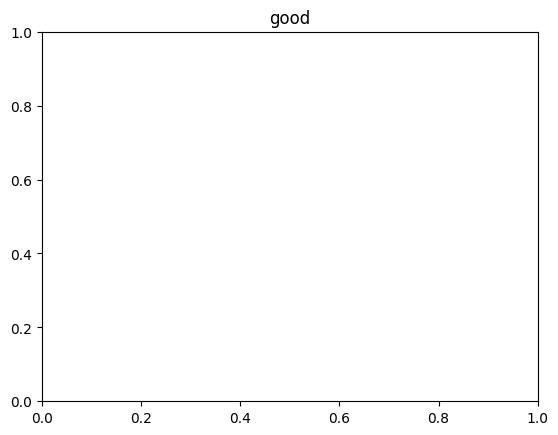

In [10]:
fig, ax = plt.subplots()
title = ax.set_title("test")
title.set_text("good")

In [2]:
def dummy_work_function(x, y):
    if y is None:
        return x
    else:
        return x + y

In [3]:
with ProcessPoolExecutor(max_workers=1) as executor:
    results = list(executor.map(dummy_work_function, [1,2,3], [None]*3))
results

[1, 2, 3]

In [4]:
vbi_gband_xshift, vbi_gband_yshift = 4.40*u.arcsec, 1.46*u.arcsec

# fake header for reprojection, we don't have to reproject to a resolution similar to DKIST
# for AIA and IRIS as the angle of separation is very small, we let them have the same rsun_ref

dkist_vbi_target_header = fits.getheader("/cluster/scratch/zhuyin/pid_1_123/AEZDV/VBI_2022_10_24T18_59_10_640_00430500_I_AEZDV_L1.fits", ext=1)
dkist_vbi_target_header["CRVAL1"] = dkist_vbi_target_header["CRVAL1"] + vbi_gband_xshift.to_value(u.arcsec)
dkist_vbi_target_header["CRVAL2"] = dkist_vbi_target_header["CRVAL2"] + vbi_gband_yshift.to_value(u.arcsec)
dkist_vbi_target_header["NAXIS"] = 2
dkist_vbi_target_header.remove("NAXIS3")

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((8,8))

dkist_vbi_target_header["rsun_ref"] = 695700000 + 4.7e6 # increase some height to have a better result
dkist_vbi_target_cube_47 = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_47_crop = dkist_vbi_target_cube_47[128:-128,128:-128]
dkist_vbi_target_cube_47_crop_rebin = dkist_vbi_target_cube_47_crop.rebin((8,8))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [5]:
dkist_vbi_target_header.tofile("../../sav/dkist_vbi_target_header.fits", overwrite=True)

In [6]:
fits.getheader("../../sav/dkist_vbi_target_header.fits", ignore_missing_simple=True)

XTENSION= 'IMAGE   '                                                            
BITPIX  =                  -32                                                  
NAXIS   =                    2                                                  
NAXIS1  =                 4096 / [pix]                                          
NAXIS2  =                 4096 / [pix]                                          
PCOUNT  =                    0                                                  
GCOUNT  =                    1                                                  
BUNIT   = 'ct      '                                                            
DATE    = '2024-06-10T20:19:57.899'                                             
DATE-BEG= '2022-10-24T18:59:10.640'                                             
DATE-END= '2022-10-24T18:59:10.640697'                                          
TELAPSE = 0.000697164796292781 / [s]                                            
DATE-AVG= '2022-10-24T18:59:

In [5]:
file_TiO_destretched = h5py.File("/cluster/scratch/zhuyin/pid_1_123/BNRPZ_aligned/BNRPZ_aligned_all.h5")
TiO_dset = file_TiO_destretched["vbi_img"]
TiO_da = da.from_array(TiO_dset, chunks=(1, 4096, 4096))

TiO_dset_raw = dkist.load_dataset("/cluster/scratch/zhuyin/pid_1_123/BNRPZ")

TiO_ds_raw_header_0 = fits.getheader("/cluster/scratch/zhuyin/pid_1_123/BNRPZ/VBI_2022_10_24T18_58_12_753_00705800_I_BNRPZ_L1.fits", ext=1)
TiO_ds_raw_header_0["CDELT1"] = TiO_ds_raw_header_0["CDELT1"]*1.1075
TiO_ds_raw_header_0["CDELT2"] = TiO_ds_raw_header_0["CDELT2"]*1.1075
TiO_ds_raw_header_0["CRVAL1"] = TiO_ds_raw_header_0["CRVAL1"] - 13 + \
    (-140.1 - 15.2)*TiO_ds_raw_header_0["CDELT1"]*TiO_ds_raw_header_0["PC1_1"] + \
    (-125.1)*TiO_ds_raw_header_0["CDELT2"]*TiO_ds_raw_header_0["PC1_2"] + 4.4
TiO_ds_raw_header_0["CRVAL2"] = TiO_ds_raw_header_0["CRVAL2"] - 15 + \
    (-140.1 - 15.2)*TiO_ds_raw_header_0["CDELT1"]*TiO_ds_raw_header_0["PC2_1"] + \
    (-125.1)*TiO_ds_raw_header_0["CDELT2"]*TiO_ds_raw_header_0["PC2_2"] + 1.46 # crude estimation
TiO_ds_raw_header_0.remove("NAXIS3")

TiO_ds_wcs = WCS(TiO_ds_raw_header_0, naxis=2)

Set MJD-BEG to 59876.790425 from DATE-BEG.
Set MJD-AVG to 59876.790425 from DATE-AVG.
Set MJD-END to 59876.790425 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [8]:
TiO_dset_raw.headers[["DATE-AVG",]].write("../../sav/vbi_table_test.txt", format="ascii", overwrite=True)

In [6]:
file_Gband_destretched = h5py.File("/cluster/scratch/zhuyin/pid_1_123/AEZDV_aligned/AEZDV_aligned_all.h5")
Gband_dset = file_Gband_destretched["vbi_img"]
Gband_da = da.from_array(Gband_dset, chunks=(1, 4096, 4096))

Gband_dset_raw = dkist.load_dataset("/cluster/scratch/zhuyin/pid_1_123/AEZDV/")

In [10]:
eui_files = sorted(glob("/cluster/home/zhuyin/scratch/pid_1_123_aux/HRI/coalign_step_boxcar/*.fits"))[:10]
n_eui_files = len(eui_files)
eui_map_seq_coalign = sunpy.map.Map(eui_files[:],sequence=False,memmap=True)

Txshift_hri, Tyshift_hri = (1.66986 + 2.49223)*u.arcsec,(7.60204 - 2.76366 - 1.0 )*u.arcsec

eui_map_181 = eui_map_seq_coalign[0].shift_reference_coord(Txshift_hri,Tyshift_hri)
eui_map_181.meta["rsun_ref"] = 695700000 + 4.7e6
eui_map_wcs = eui_map_181.wcs

In [12]:
eui_map_wcs.to_header().tofile("../../sav/hri_nocrop_noproj_wcs.fits", overwrite=True)

In [13]:
eui_cube_181 = NDCube(eui_map_181.data, eui_map_181.wcs)

In [14]:
map_new = eui_cube_181[500:750,1050:1360].reproject_to(dkist_vbi_target_cube_crop_rebin.wcs)

In [15]:
dkist_vbi_target_cube_47_crop.wcs.pixel_to_world(0,0)

<SkyCoord (Helioprojective: obstime=2022-10-24T18:59:10.640, rsun=700400.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-10-24T18:59:10.640, rsun=700400.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.00204026, 5.0951742, 1.48793988e+11)>): (Tx, Ty) in arcsec
    (-412.84544676, 178.61772723)>

In [16]:
with propagate_with_solar_surface():
    print(np.floor(eui_map_wcs.world_to_pixel(dkist_vbi_target_cube_47_crop.wcs.pixel_to_world(0,0))).astype("int"))
    print(np.ceil(eui_map_wcs.world_to_pixel(dkist_vbi_target_cube_47_crop.wcs.pixel_to_world(4096 - 1 - 128*2,4096 - 1 -128*2))).astype("int"))

[1144  513]
[1311  736]


In [17]:
with propagate_with_solar_surface():
    hrieuv_no_proj_left_bottom_x, _ = \
    np.floor(eui_map_wcs.world_to_pixel(dkist_vbi_target_cube_47_crop.wcs.pixel_to_world(0,4096-1-128*2))).astype("int")

    _, hrieuv_no_proj_left_bottom_y = \
    np.floor(eui_map_wcs.world_to_pixel(dkist_vbi_target_cube_47_crop.wcs.pixel_to_world(0,0))).astype("int")

    hrieuv_no_proj_top_right_x, _ = \
    np.ceil(eui_map_wcs.world_to_pixel(dkist_vbi_target_cube_47_crop.wcs.pixel_to_world(4096-1-128*2,0))).astype("int")

    _, hrieuv_no_proj_top_right_y = \
    np.ceil(eui_map_wcs.world_to_pixel(dkist_vbi_target_cube_47_crop.wcs.pixel_to_world(4096-1-128*2,4096-1-128*2))).astype("int")

    hrieuv_no_proj_extent = [hrieuv_no_proj_left_bottom_x, hrieuv_no_proj_left_bottom_y,
                            hrieuv_no_proj_top_right_x, hrieuv_no_proj_top_right_y]

In [18]:
hrieuv_no_proj_extent

[1105, 513, 1349, 736]

In [11]:
def job_hrieuv_wow_and_reproject(map_raw, map_wcs, target_wcs):
    hrieuv_map = NDCube(map_raw.data, map_wcs)
    hrieuv_map_date_ear = map_raw.meta["date_ear"]
    hrieuv_map = hrieuv_map[500:750,1050:1360]
    
    hrieuv_map = NDCube(wow(hrieuv_map.data, bilateral=1, denoise_coefficients=[5,5],)[0],
                               hrieuv_map.wcs)
    
    with propagate_with_solar_surface():
        hrieuv_map = hrieuv_map.reproject_to(target_wcs,algorithm="adaptive")
    
    return (hrieuv_map.data, hrieuv_map_date_ear)

In [12]:
with ProcessPoolExecutor(max_workers=10) as executor:
    results = executor.map(job_hrieuv_wow_and_reproject, eui_map_seq_coalign, [eui_map_wcs]*n_eui_files, [dkist_vbi_target_cube_crop_rebin.wcs]*n_eui_files)
    results_list = list(results)
    # hrieuv_pr_dset = np.array([r[0] for r in list(results)])
    hrieuv_date_ear = [r[1] for r in list(results)]

Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 fro

In [13]:
results_list[0][1]

'2022-10-24T19:05:01.308'

In [14]:
time_list = [r[1] for r in results_list]

In [15]:
time_table = Table()
time_table["time"] = time_list
time_table

time
str23
2022-10-24T19:05:01.308
2022-10-24T19:05:06.308
2022-10-24T19:05:11.307
2022-10-24T19:05:16.306
2022-10-24T19:05:21.307
2022-10-24T19:05:26.306
2022-10-24T19:05:31.306
2022-10-24T19:05:36.306
2022-10-24T19:05:41.305


In [3]:
iris_sji_1400_cube = read_iris_sji("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/IRIS/iris_l2_20221024_190447_3643101203_SJI_1400_t000.fits",sdo_rsun=False)

In [5]:
iris_sji_1400_cube = sunpy.map.Map(iris_sji_1400_cube, sequence=True)

In [8]:
iris_sji_1400_cube.data.shape

(386, 364, 477)

In [23]:
iris_sji_1400_cube_data_despike = iris_prep_despike(iris_sji_1400_cube.data, sigmas=4, mode="both",
kernel=np.ones((7,7,7)))

Wed Oct 22 12:51:14 2025 IRIS_PREP_DESPIKE started on array of 67020408 elements.
Step (1): Iteratively identifying bad pixels.
Iteration    1 found        84364 bad pixels,        84364 of them new.
Iteration    2 found       168545 bad pixels,        84184 of them new.
Iteration    3 found       240524 bad pixels,        71981 of them new.
Iteration    4 found       288663 bad pixels,        48141 of them new.
Iteration    5 found       313037 bad pixels,        24385 of them new.
Iteration    6 found       322992 bad pixels,         9960 of them new.
Iteration    7 found       326563 bad pixels,         3574 of them new.
Iteration    8 found       327767 bad pixels,         1207 of them new.
Iteration    9 found       328170 bad pixels,          404 of them new.
Iteration   10 found       328315 bad pixels,          145 of them new.
Step (2): Replacing bad pixels
Wed Oct 22 13:05:06 2025 IRIS_PREP_DESPIKE finished, 832.02 sec elapsed.


In [17]:
iris_sji_1400_cube_data_despike.shape

(386, 364, 477)

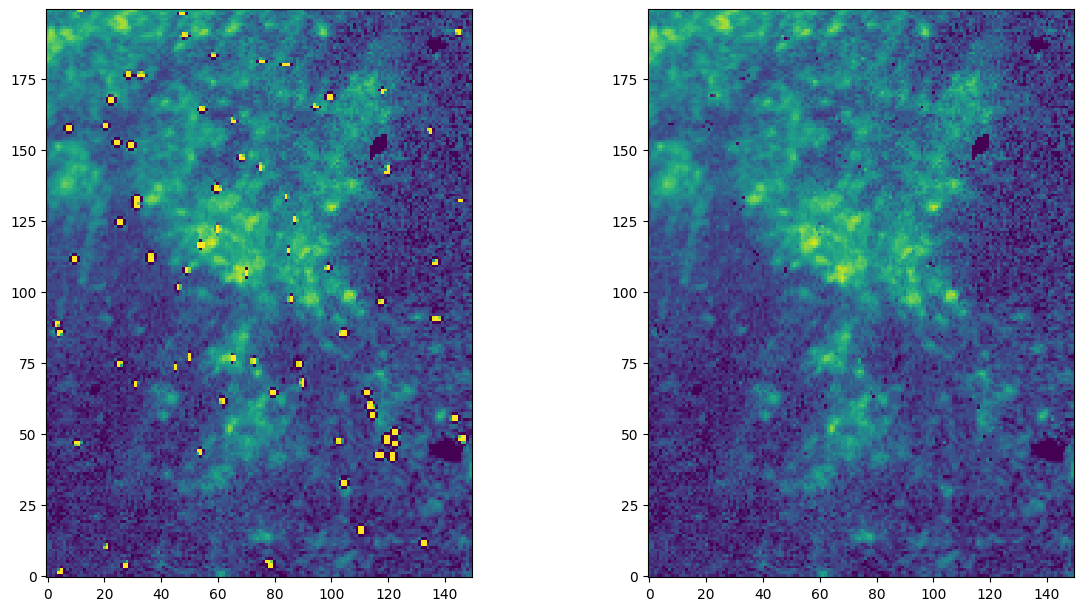

In [24]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,6), layout="constrained")

ax1.imshow(iris_sji_1400_cube[400].data[100:300, 200:350], origin="lower",
        norm=ImageNormalize(
            vmin=0, 
            vmax=30, 
            stretch=AsinhStretch(),
        ),
        interpolation="none")
ax2.imshow(iris_sji_1400_cube_data_despike[100:300, 200:350, 400], origin="lower",
        norm=ImageNormalize(
            vmin=0, 
            vmax=30, 
            stretch=AsinhStretch()
        ),
        interpolation="none")

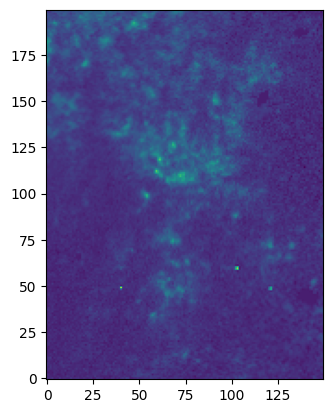

In [ ]:
plt.imshow(iris_sji_1400_cube[0].data[100:300, 200:350], origin="lower")

In [ ]:
def job_irissji_wow_and_reproject(map_raw, map_wcs, target_wcs):
    irissji_map = NDCube(map_raw.data, map_wcs)
    irissji_map_date = map_raw.meta["date-obs"]
    irissji_map = irissji_map[100:300,150:350]
    
    irissji_map = NDCube(wow(irissji_map.data, bilateral=1, denoise_coefficients=[5,5],)[0],
                               irissji_map.wcs)
    
    with propagate_with_solar_surface():
        irissji_map = irissji_map.reproject_to(target_wcs,algorithm="adaptive")
    
    return (irissji_map.data, irissji_map_date)

In [ ]:
len(iris_sji_1400_cube)

477

In [ ]:
test_iris_map = job_irissji_wow_and_reproject(iris_sji_1400_cube[0], iris_sji_1400_cube[0].wcs, dkist_vbi_target_cube_crop_rebin.wcs)

In [ ]:
with ProcessPoolExecutor(max_workers=10) as executor:
    results = executor.map(job_irissji_wow_and_reproject, iris_sji_1400_cube[:10], [iris_sji_1400_cube[0].wcs]*10, [dkist_vbi_target_cube_crop_rebin.wcs]*10)
    results_list = list(results)

Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]: FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to  -156.256400 from OBSGEO-[XYZ].
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]

Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
WARNING
: FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to  -156.256400 from OBSGEO-[XYZ].
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]WARNING: FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to  -156.256400 from OBSGEO-[XYZ].
Set OBSGEO-B t

In [ ]:
irissji_maps = np.array([r[0] for r in results_list])
irissji_date_ear = [r[1] for r in results_list]

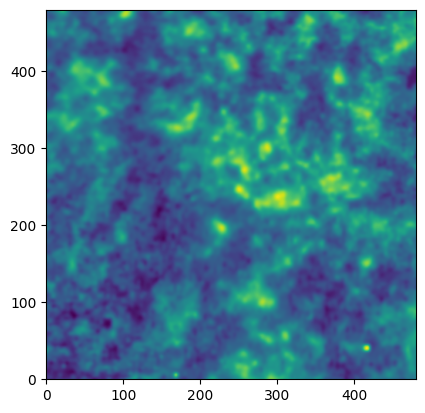

In [ ]:
plt.imshow(irissji_maps[0], origin="lower")

In [ ]:
aia_171_cube = sunpy.map.Map(sorted(glob("/cluster/scratch/zhuyin/pid_1_123_aux/AIA/171/*.fits"))[:10],sequence=False,
                            memmap=True)

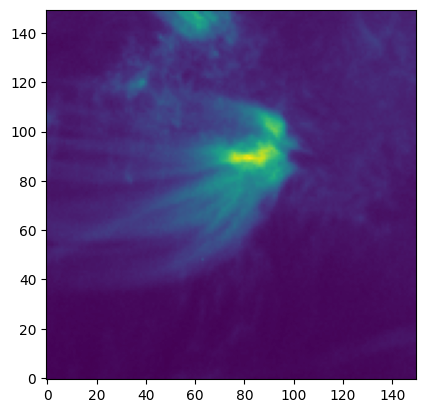

In [ ]:
plt.imshow(aia_171_cube[0].data[250:400,280:430], origin="lower")

In [ ]:
def job_aia_wow_and_reproject(map_raw, map_wcs, target_wcs):
    aia_map = NDCube(map_raw.data, map_wcs)
    aia_map_date = map_raw.meta["date-obs"]
    aia_map = aia_map[250:400,280:430]
    
    aia_map = NDCube(wow(aia_map.data, bilateral=1, denoise_coefficients=[5,5],)[0],
                               aia_map.wcs)
    
    with propagate_with_solar_surface():
        aia_map = aia_map.reproject_to(target_wcs,algorithm="adaptive")
    
    return (aia_map.data, aia_map_date)

In [ ]:
test_aia_map, test_aia_date = job_aia_wow_and_reproject(aia_171_cube[0], aia_171_cube[0].wcs, dkist_vbi_target_cube_crop_rebin.wcs)

In [ ]:
test_aia_date

'2022-10-24T19:04:09.352'

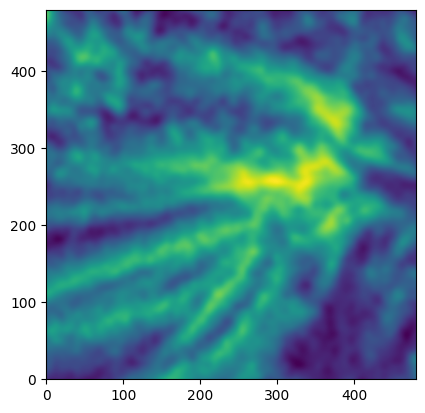

In [ ]:
plt.imshow(test_aia_map, origin="lower")

In [11]:
def job_reproj_vbir_to_vbib(vbir_data, vbir_wcs, target_wcs, shift):
    if shift is not None:
        vbir_map = NDCube(ndimage.shift(vbir_data, shift), vbir_wcs)
    else:
        vbir_map = NDCube(vbir_data, vbir_wcs)

    vbir_map = vbir_map.reproject_to(target_wcs,algorithm="adaptive")
    return vbir_map

In [12]:
vbir_map_test = job_reproj_vbir_to_vbib(TiO_da[9], TiO_ds_wcs, dkist_vbi_target_cube.wcs, (0,0))

In [14]:
with ProcessPoolExecutor(max_workers=1) as executor:
    vbir_map_results = np.array(list(executor.map(job_reproj_vbir_to_vbib, TiO_da[:2].compute(), [TiO_ds_wcs]*2, [dkist_vbi_target_cube.wcs]*2, [None]*2)))

Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [24]:
ImageBlinker(vbir_map_test.data[1536:2536, 1736:2736], Gband_da[0, 1536:2536, 1736:2736].compute())

In [25]:
shift_vbir_vbiblue, _, _ = phase_cross_correlation(vbir_map_test.data[1536:2536, 1736:2736], Gband_da[0, 1536:2536, 1736:2736].compute(),
                                                   upsample_factor=10)
shift_vbir_vbiblue

array([-0.2, -0.1])